<a href="https://colab.research.google.com/github/chetankhairnar05/Colab/blob/main/ml_lab_external_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0801CS231039 Chetan Khairnar

9= Support Vector Machines, Target variable =  status
Perform the following tasks on the shared dataset.
a) Basic Exploratory Data Analysis[01]
b) Visualization[02]
c) Data Wrangling/Preprocessing[03]
d) Apply the Model.[02]
e) Evaluate[01]
f) Tune HyperParameter[01]



dataset = Placement_Data_Full_Class


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/Placement_Data_Full_Class - Placement_Data_Full_Class.csv")
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [2]:
df.tail()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
210,211,M,80.6,Others,82.0,Others,Commerce,77.6,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.0,Others,60.0,Others,Science,72.0,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.0,Others,67.0,Others,Commerce,73.0,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.0,Others,66.0,Others,Commerce,58.0,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0
214,215,M,62.0,Central,58.0,Others,Science,53.0,Comm&Mgmt,No,89.0,Mkt&HR,60.22,Not Placed,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           214 non-null    float64
 3   ssc_b           210 non-null    object 
 4   hsc_p           207 non-null    float64
 5   hsc_b           203 non-null    object 
 6   hsc_s           203 non-null    object 
 7   degree_p        192 non-null    float64
 8   degree_t        202 non-null    object 
 9   workex          202 non-null    object 
 10  etest_p         202 non-null    float64
 11  specialisation  200 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          212 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [4]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,214.000000,207.000000,192.000000,202.000000,215.000000,148.000000
mean,108.000000,67.346869,66.206908,66.196823,71.873515,62.278186,288655.405405
std,62.209324,10.833766,11.040082,7.505782,13.247191,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.850000,60.415000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,65.800000,70.000000,62.000000,265000.000000
75%,161.500000,75.850000,73.000000,72.000000,83.000000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [5]:
df.isna().sum()

,0
sl_no,0
gender,0
ssc_p,1
ssc_b,5
hsc_p,8
hsc_b,12
hsc_s,12
degree_p,23
degree_t,13
workex,13


In [6]:
# remove the null rows of status because it will be our target variable
df.dropna(subset=['status'], inplace=True)

In [8]:
#create variables num_col, and cat_col and then insert the numerical and categorical(object) data type columns name in it
num_col = []
cat_col = []
for i in df.columns:
  if df[i].dtype == 'int64' or df[i].dtype == 'float64':
    num_col.append(i)
  else :
    cat_col.append(i)
print(num_col)
print(cat_col)

['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']
['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']


In [9]:
#do mean imputation in num_col and mode imputation in cat_col columns
for i in num_col:
  df[i].fillna(df[i].mean(), inplace=True)
  print(i)
for i in cat_col:
  df[i].fillna(df[i].mode()[0], inplace=True)
  print(i)


sl_no
ssc_p
hsc_p
degree_p
etest_p
mba_p
salary
gender
ssc_b
hsc_b
hsc_s
degree_t
workex
specialisation
status


/tmp/ipykernel_1142/153704000.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mean(), inplace=True)
/tmp/ipykernel_1142/153704000.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

In [10]:
df.isna().sum()

,0
sl_no,0
gender,0
ssc_p,0
ssc_b,0
hsc_p,0
hsc_b,0
hsc_s,0
degree_p,0
degree_t,0
workex,0


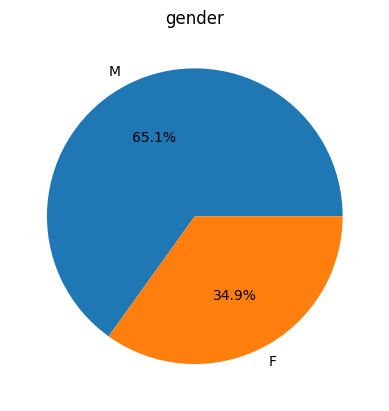

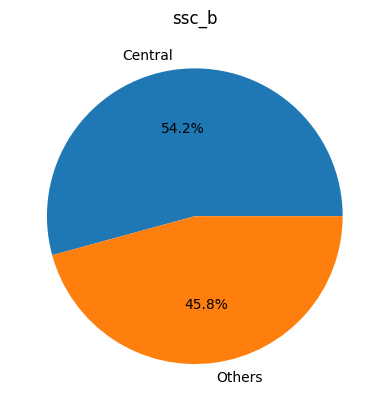

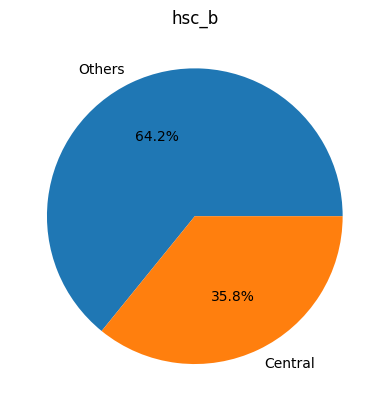

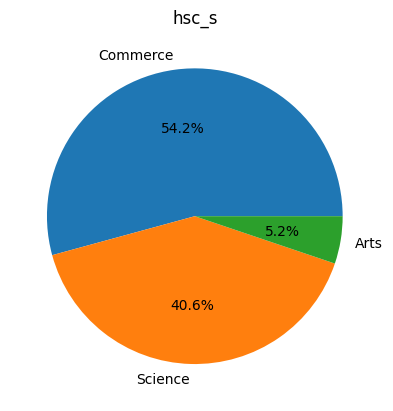

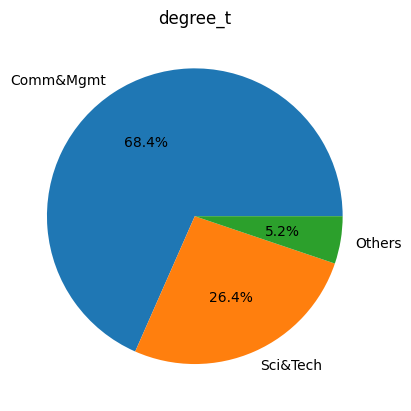

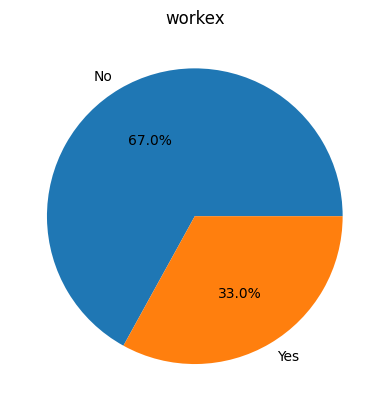

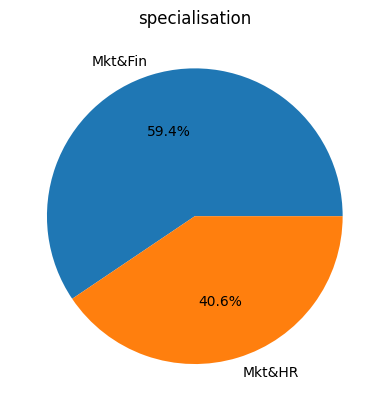

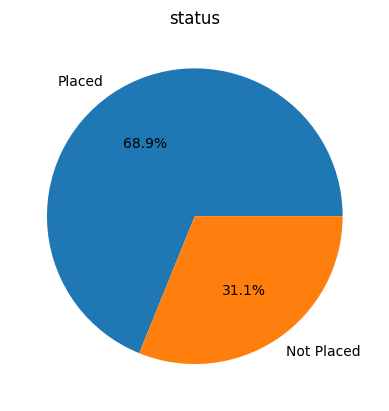

In [11]:
# make pi chart for all cat_cols
for i in cat_col:
  plt.pie(df[i].value_counts(), labels=df[i].value_counts().index
          , autopct='%1.1f%%')
  plt.title(i)
  plt.show()

<Axes: >

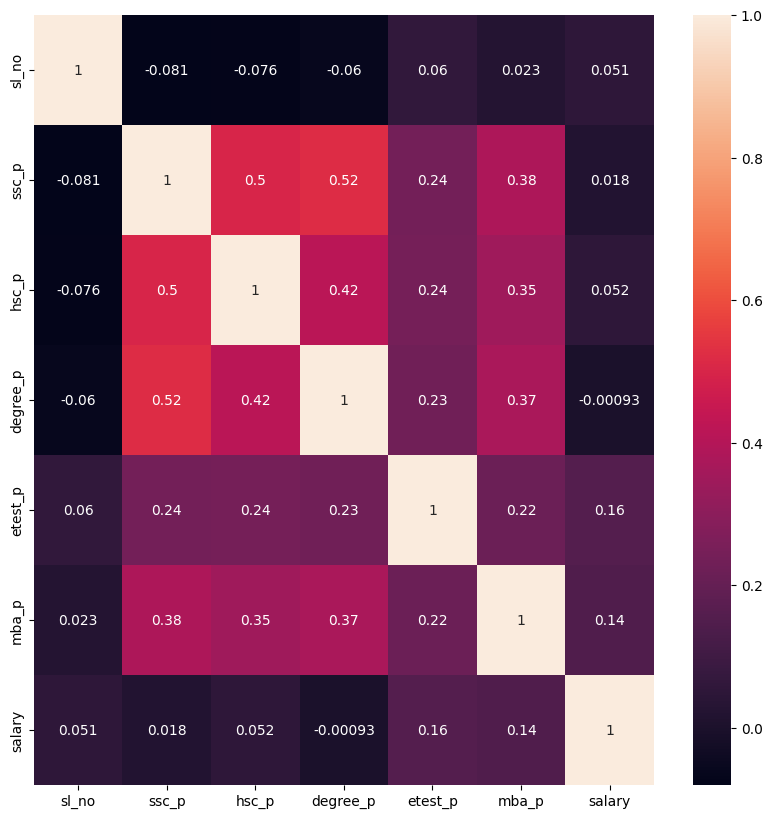

In [12]:
#make correlation chart of this matrix of size 10*10
plt.figure(figsize=(10,10))
sns.heatmap(df[num_col].corr(), annot=True)


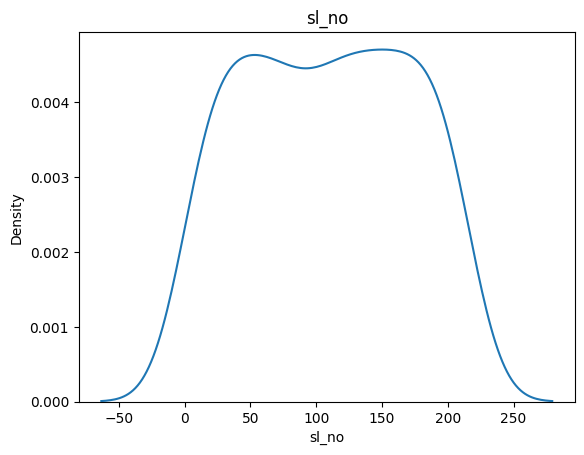

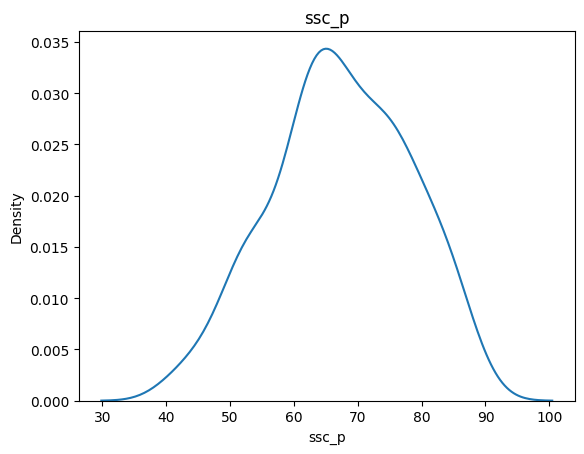

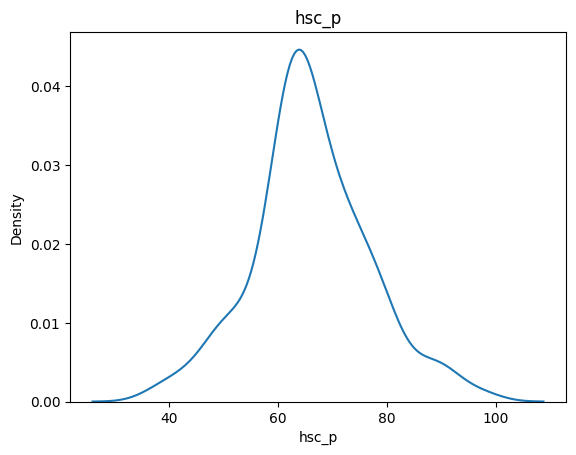

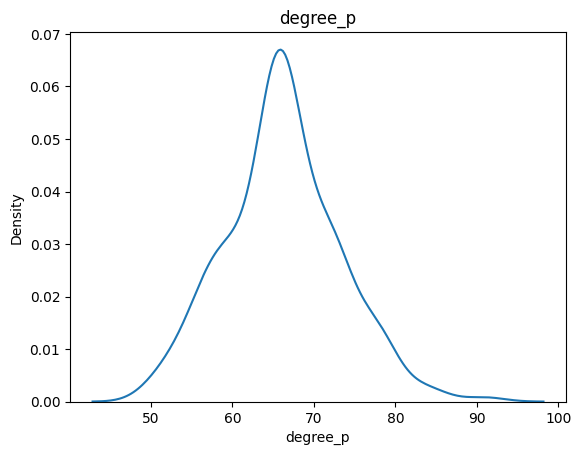

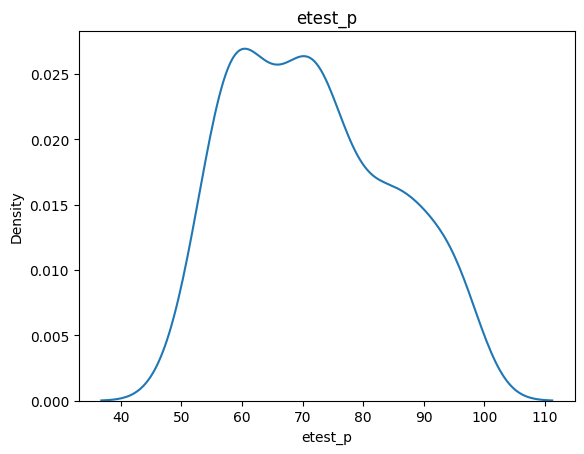

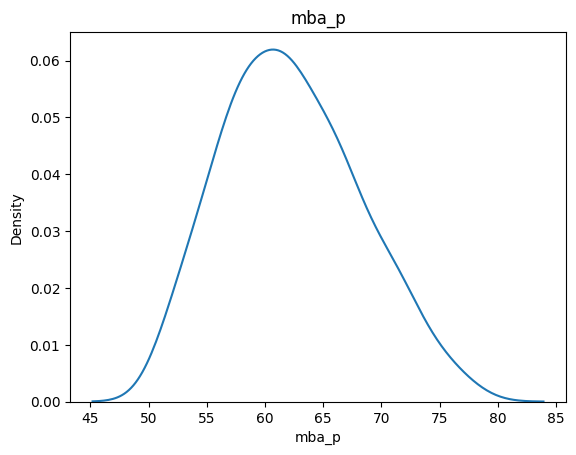

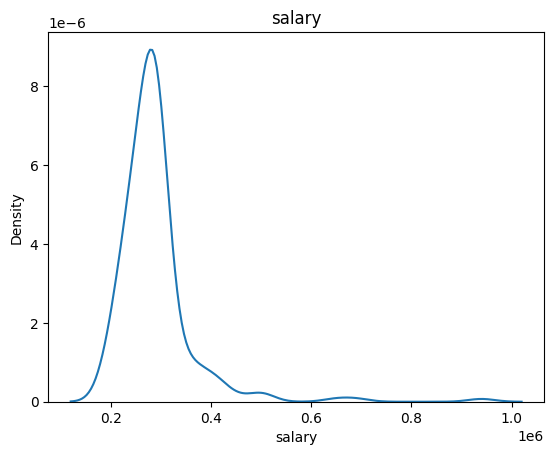

In [13]:
# make kde plot for all the columns present in num_col
for i in num_col:
  sns.kdeplot(df[i])
  plt.title(i)
  plt.show()


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           212 non-null    int64  
 1   gender          212 non-null    object 
 2   ssc_p           212 non-null    float64
 3   ssc_b           212 non-null    object 
 4   hsc_p           212 non-null    float64
 5   hsc_b           212 non-null    object 
 6   hsc_s           212 non-null    object 
 7   degree_p        212 non-null    float64
 8   degree_t        212 non-null    object 
 9   workex          212 non-null    object 
 10  etest_p         212 non-null    float64
 11  specialisation  212 non-null    object 
 12  mba_p           212 non-null    float64
 13  status          212 non-null    object 
 14  salary          212 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 26.5+ KB


In [15]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000
mean,108.226415,67.369668,66.121716,66.195714,71.796231,62.261887,288979.452055
std,62.620467,10.754035,10.764128,6.977785,12.850410,5.858030,77897.640284
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,53.750000,61.000000,60.950000,61.195000,60.000000,57.875000,250000.000000
50%,109.500000,67.000000,65.000000,66.195714,71.498116,61.950000,288979.452055
75%,162.250000,75.550000,73.000000,70.752500,82.000000,66.242500,288979.452055
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [16]:
# print how many categories are in each col of cat_col
for i in cat_col:
  print(i, df[i].nunique())

gender 2
ssc_b 2
hsc_b 2
hsc_s 3
degree_t 3
workex 2
specialisation 2
status 2


In [17]:
#do one hot encoding of all this categorical columns except status column it is our target variable do label encoding of it
for i in cat_col[:-1]:
  df = pd.get_dummies(df, columns=[i], prefix=[i],drop_first=True)



In [18]:
df.head()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,status,salary,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
0,1,67.00,91.00,58.00,55.0,58.80,Placed,270000.000000,True,True,True,True,False,False,True,False,True
1,2,79.33,78.33,77.48,86.5,66.28,Placed,200000.000000,True,False,True,False,True,False,True,True,False
2,3,65.00,68.00,64.00,75.0,57.80,Placed,250000.000000,True,False,False,False,False,False,False,False,False
3,4,56.00,52.00,52.00,66.0,59.43,Not Placed,288979.452055,True,False,False,False,True,False,True,False,True
4,5,85.80,73.60,73.30,96.8,55.50,Placed,425000.000000,True,False,False,True,False,False,False,False,False


In [19]:
#do label encoding of placed column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

In [20]:
df.head()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,status,salary,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
0,1,67.00,91.00,58.00,55.0,58.80,1,270000.000000,True,True,True,True,False,False,True,False,True
1,2,79.33,78.33,77.48,86.5,66.28,1,200000.000000,True,False,True,False,True,False,True,True,False
2,3,65.00,68.00,64.00,75.0,57.80,1,250000.000000,True,False,False,False,False,False,False,False,False
3,4,56.00,52.00,52.00,66.0,59.43,0,288979.452055,True,False,False,False,True,False,True,False,True
4,5,85.80,73.60,73.30,96.8,55.50,1,425000.000000,True,False,False,True,False,False,False,False,False


In [21]:
#due to ohe the columns are of boolean type make them numerical type ie o , 1
for i in df.columns:
  if i not in num_col:
    df[i] = df[i].astype(int)

In [22]:
df.head()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,status,salary,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
0,1,67.00,91.00,58.00,55.0,58.80,1,270000.000000,1,1,1,1,0,0,1,0,1
1,2,79.33,78.33,77.48,86.5,66.28,1,200000.000000,1,0,1,0,1,0,1,1,0
2,3,65.00,68.00,64.00,75.0,57.80,1,250000.000000,1,0,0,0,0,0,0,0,0
3,4,56.00,52.00,52.00,66.0,59.43,0,288979.452055,1,0,0,0,1,0,1,0,1
4,5,85.80,73.60,73.30,96.8,55.50,1,425000.000000,1,0,0,1,0,0,0,0,0


In [23]:
# make y = status column and X = rest of columns of df
X = df.drop('status', axis=1)
y = df['status']



In [24]:
# do train test split of this X and y with stratify = y
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [26]:
#apply svm on this data do some hyperparameter training
from sklearn.svm import SVC
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_breast_cancer

model = SVC()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.70      1.00      0.82        30

    accuracy                           0.70        43
   macro avg       0.35      0.50      0.41        43
weighted avg       0.49      0.70      0.57        43



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 100, 1000],
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
			'kernel': ['rbf']}

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.706 total time=   0.1s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.676 total time=   0.1s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.676 total time=   0.1s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.676 total time=   0.1s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.697 total time=   0.1s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.706 total time=   0.1s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.676 total time=   0.1s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.676 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.676 total time=   0.1s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.697 total time=   0.1s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.706 total time=   0.1s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [28]:
print(grid.best_params_)

print(grid.best_estimator_)

{'C': 0.1, 'gamma': 0.0001, 'kernel': 'rbf'}
SVC(C=0.1, gamma=0.0001)


In [29]:
grid_predictions = grid.predict(X_test)

print(classification_report(y_test, grid_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        30

    accuracy                           1.00        43
   macro avg       1.00      1.00      1.00        43
weighted avg       1.00      1.00      1.00        43

